In [ ]:
# ==========================================================
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================================
# En esta sección cargamos las herramientas necesarias para:
# - leer datos
# - limpiarlos y prepararlos
# - visualizarlos
# - entrenar modelos de regresión lineal y logística
# - evaluar resultados

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)
from sklearn.preprocessing import StandardScaler

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [ ]:
# ==========================================================
# CARGA DE DATOS DESDE ARCHIVO CSV
# ==========================================================
# Instrucción para el equipo:
# 1. Subir el archivo CSV a Google Colab
# 2. Copiar la ruta del archivo
# 3. Pegarla en la variable file_path
#
# Como el archivo es .csv, usamos pd.read_csv()

file_path = "/content/Walmart.csv"   # <-- CAMBIAR ESTA RUTA SI ES NECESARIO

df = pd.read_csv(file_path)

print("Dataset cargado correctamente.")
display(df.head())

Dataset cargado correctamente.


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Unnamed: 8,Unnamed: 9,investigar,Unnamed: 11
0,1,05/02/2010,1643690.90,0,42.31,2.572,211.096358,8.106,NaN,NaN,NaN,NaN
1,1,12/02/2010,1641957.44,1,38.51,2.548,211.242170,8.106,NaN,NaN,5.0,tienda mty
2,1,19/02/2010,1611968.17,0,39.93,2.514,211.289143,8.106,NaN,NaN,NaN,NaN
3,1,26/02/2010,1409727.59,0,46.63,2.561,211.319643,8.106,NaN,NaN,NaN,NaN
4,1,05/03/2010,1554806.68,0,46.50,2.625,211.350143,8.106,NaN,NaN,NaN,NaN


In [ ]:
# ==========================================================
# EXPLORACIÓN INICIAL
# ==========================================================
# Antes de modelar, debemos entender la estructura del dataset:
# - cuántas filas y columnas tiene
# - qué tipo de variables contiene
# - si existen valores faltantes
# - si hay duplicados
# - cómo se comportan estadísticamente las variables numéricas

print("Dimensiones del dataset:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)

print("\nValores faltantes por columna:")
print(df.isnull().sum())

print("\nFilas duplicadas:", df.duplicated().sum())

print("\nResumen estadístico:")
display(df.describe(include='all'))

Dimensiones del dataset: (6435, 12)

Tipos de datos:
Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
Unnamed: 8      float64
Unnamed: 9      float64
investigar      float64
Unnamed: 11      object
dtype: object

Valores faltantes por columna:
Store              0
Date               0
Weekly_Sales       0
Holiday_Flag       0
Temperature        0
Fuel_Price         0
CPI                0
Unemployment       0
Unnamed: 8      6435
Unnamed: 9      6435
investigar      6434
Unnamed: 11     6434
dtype: int64

Filas duplicadas: 0

Resumen estadístico:


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Unnamed: 8,Unnamed: 9,investigar,Unnamed: 11
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,0.0,0.0,1.0,1
unique,NaN,143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
top,NaN,05/02/2010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tienda mty
freq,NaN,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
mean,23.000000,NaN,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151,NaN,NaN,5.0,NaN
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885,NaN,NaN,NaN,NaN
min,1.000000,NaN,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000,NaN,NaN,5.0,NaN
25%,12.000000,NaN,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000,NaN,NaN,5.0,NaN
50%,23.000000,NaN,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000,NaN,NaN,5.0,NaN
75%,34.000000,NaN,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000,NaN,NaN,5.0,NaN


In [ ]:
# ==========================================================
# LIMPIEZA Y PREPARACIÓN DE DATOS
# ==========================================================
# En esta etapa:
# - convertimos la fecha a formato datetime
# - eliminamos duplicados
# - creamos variables temporales útiles
# - revisamos de nuevo valores nulos

# Eliminar duplicados si existen
df = df.drop_duplicates()

# Convertir Date a formato fecha
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

# Crear variables derivadas del tiempo
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Quarter"] = df["Date"].dt.quarter

print("Valores faltantes después de convertir fecha:")
print(df.isnull().sum())

display(df.head())

Valores faltantes después de convertir fecha:
Store              0
Date               0
Weekly_Sales       0
Holiday_Flag       0
Temperature        0
Fuel_Price         0
CPI                0
Unemployment       0
Unnamed: 8      6435
Unnamed: 9      6435
investigar      6434
Unnamed: 11     6434
Year               0
Month              0
Week               0
Quarter            0
dtype: int64


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Unnamed: 8,Unnamed: 9,investigar,Unnamed: 11,Year,Month,Week,Quarter
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,NaN,NaN,NaN,NaN,2010,2,5,1
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,NaN,NaN,5.0,tienda mty,2010,2,6,1
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,NaN,NaN,NaN,NaN,2010,2,7,1
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,NaN,NaN,NaN,NaN,2010,2,8,1
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,NaN,NaN,NaN,NaN,2010,3,9,1


Promedio de Weekly_Sales: 1046964.88
Mediana de Weekly_Sales: 960746.04


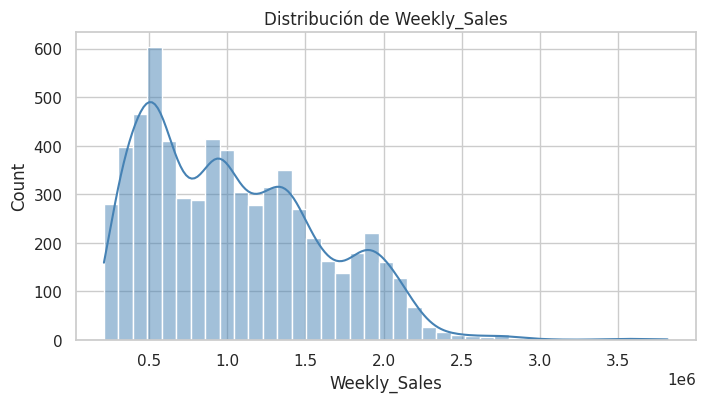

/tmp/ipykernel_17850/3378695486.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Holiday_Flag", y="Weekly_Sales", palette="pastel")


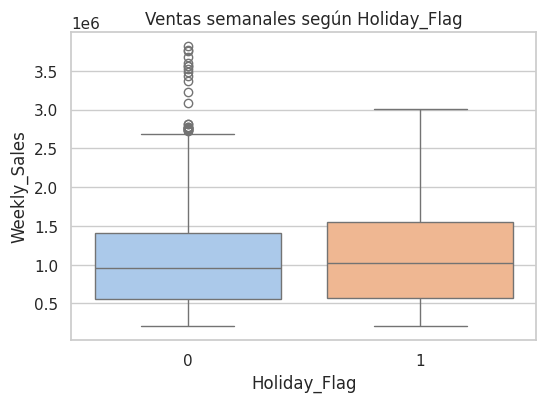

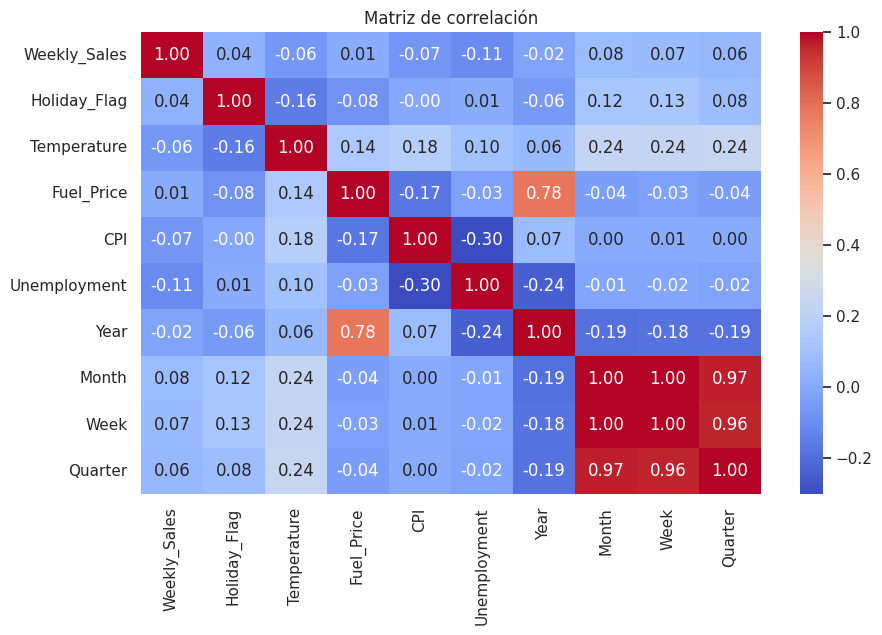

In [ ]:
# ==========================================================
# ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ==========================================================
# Aquí buscamos patrones iniciales:
# - distribución de ventas
# - relación entre variables numéricas
# - comportamiento de ventas en semanas normales vs festivas

print("Promedio de Weekly_Sales:", round(df["Weekly_Sales"].mean(), 2))
print("Mediana de Weekly_Sales:", round(df["Weekly_Sales"].median(), 2))

# Histograma de ventas
plt.figure(figsize=(8,4))
sns.histplot(df["Weekly_Sales"], kde=True, color="steelblue")
plt.title("Distribución de Weekly_Sales")
plt.show()

# Boxplot por Holiday_Flag
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Holiday_Flag", y="Weekly_Sales", palette="pastel")
plt.title("Ventas semanales según Holiday_Flag")
plt.show()

# Mapa de correlaciones
plt.figure(figsize=(10,6))
corr = df[["Weekly_Sales", "Holiday_Flag", "Temperature", "Fuel_Price", "CPI", "Unemployment", "Year", "Month", "Week", "Quarter"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

# Regresión Lineal

La regresión lineal busca modelar la relación entre una variable dependiente y una o más variables independientes.

## Fórmula general
\[
\hat{Y} = \beta_0 + \beta_1X_1 + \beta_2X_2 + \cdots + \beta_nX_n
\]

Donde:

- \(\hat{Y}\): valor estimado de las ventas semanales
- \(\beta_0\): intercepto
- \(\beta_i\): coeficientes del modelo
- \(X_i\): variables explicativas

## En este caso:
La variable objetivo será:

- `Weekly_Sales`

Y las variables predictoras serán:

- `Holiday_Flag`
- `Temperature`
- `Fuel_Price`
- `CPI`
- `Unemployment`
- `Month`
- `Week`
- `Quarter`

El propósito es estimar cómo cambian las ventas semanales según factores económicos, estacionales y operativos.

In [ ]:
# ==========================================================
# REGRESIÓN LINEAL: DEFINICIÓN DE X E y
# ==========================================================
# y = variable dependiente (lo que queremos predecir)
# X = variables independientes (las que explican o ayudan a predecir)

features_lineal = ["Holiday_Flag", "Temperature", "Fuel_Price", "CPI", "Unemployment", "Month", "Week", "Quarter"]
X_lin = df[features_lineal]
y_lin = df["Weekly_Sales"]

print("Variables predictoras seleccionadas:")
print(features_lineal)

display(X_lin.head())
display(y_lin.head())

Variables predictoras seleccionadas:
['Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Month', 'Week', 'Quarter']


,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Month,Week,Quarter
0,0,42.31,2.572,211.096358,8.106,2,5,1
1,1,38.51,2.548,211.242170,8.106,2,6,1
2,0,39.93,2.514,211.289143,8.106,2,7,1
3,0,46.63,2.561,211.319643,8.106,2,8,1
4,0,46.50,2.625,211.350143,8.106,3,9,1


,Weekly_Sales
0,1643690.90
1,1641957.44
2,1611968.17
3,1409727.59
4,1554806.68


In [ ]:
# ==========================================================
# REGRESIÓN LINEAL: TRAIN / TEST SPLIT
# ==========================================================
# Aquí separamos los datos en:
# - entrenamiento: para que el modelo aprenda
# - prueba: para evaluar si el modelo funciona con datos no vistos
#
# Esta separación es clave porque evita evaluar el modelo
# con los mismos datos con los que aprendió.

X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X_lin, y_lin, test_size=0.2, random_state=42
)

print("Tamaño de X_train:", X_train_lin.shape)
print("Tamaño de X_test :", X_test_lin.shape)
print("Tamaño de y_train:", y_train_lin.shape)
print("Tamaño de y_test :", y_test_lin.shape)

Tamaño de X_train: (5148, 8)
Tamaño de X_test : (1287, 8)
Tamaño de y_train: (5148,)
Tamaño de y_test : (1287,)


In [ ]:
# ==========================================================
# REGRESIÓN LINEAL: ENTRENAMIENTO DEL MODELO
# ==========================================================
# En esta parte el algoritmo estima los coeficientes beta
# de la ecuación lineal. El objetivo matemático del modelo
# es minimizar el error entre los valores reales y los predichos.

modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train_lin, y_train_lin)

# Coeficientes del modelo
coeficientes_lineales = pd.DataFrame({
    "Variable": X_train_lin.columns,
    "Coeficiente": modelo_lineal.coef_
})

print("Intercepto (β0):", modelo_lineal.intercept_)
display(coeficientes_lineales.sort_values(by="Coeficiente", ascending=False))

Intercepto (β0): 1671447.3146140764


,Variable,Coeficiente
5,Month,92375.396541
0,Holiday_Flag,45216.353749
1,Temperature,-1153.354335
3,CPI,-1560.831402
2,Fuel_Price,-8600.625050
6,Week,-11098.391412
4,Unemployment,-42433.391979
7,Quarter,-93574.096938


In [ ]:
# ==========================================================
# REGRESIÓN LINEAL: PREDICCIÓN Y EVALUACIÓN
# ==========================================================
# Una vez entrenado el modelo, hacemos predicciones sobre
# el conjunto de prueba y medimos su desempeño con métricas.

y_pred_lin = modelo_lineal.predict(X_test_lin)

mae = mean_absolute_error(y_test_lin, y_pred_lin)
mse = mean_squared_error(y_test_lin, y_pred_lin)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_lin, y_pred_lin)

print("Métricas del modelo de regresión lineal")
print(f"MAE  : {mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

resultados_lineal = pd.DataFrame({
    "Real": y_test_lin.values,
    "Predicho": y_pred_lin
})

display(resultados_lineal.head(10))

Métricas del modelo de regresión lineal
MAE  : 474,771.52
MSE  : 314,714,642,564.55
RMSE : 560,994.33
R²   : 0.0231


,Real,Predicho
0,1138800.32,1.074835e+06
1,1304850.67,1.087966e+06
2,1769296.25,9.837465e+05
3,1077640.13,1.201519e+06
4,428851.99,9.502739e+05
5,1004523.59,1.056340e+06
6,1523410.71,9.127136e+05
7,1014898.78,9.348579e+05
8,1955896.59,9.540427e+05
9,958667.23,9.839730e+05


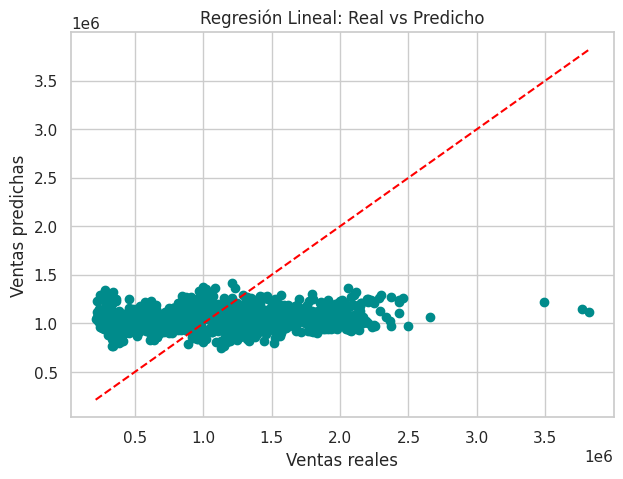

In [ ]:
# ==========================================================
# REGRESIÓN LINEAL: COMPARACIÓN REAL VS PREDICHO
# ==========================================================
# Si el modelo funciona razonablemente bien, los valores predichos
# deberían aproximarse a los valores reales.

plt.figure(figsize=(7,5))
plt.scatter(y_test_lin, y_pred_lin, color="darkcyan")
plt.xlabel("Ventas reales")
plt.ylabel("Ventas predichas")
plt.title("Regresión Lineal: Real vs Predicho")
plt.plot([y_test_lin.min(), y_test_lin.max()],
         [y_test_lin.min(), y_test_lin.max()],
         color="red", linestyle="--")
plt.show()

## Interpretación de negocio — Regresión lineal

Este modelo intenta explicar el comportamiento de `Weekly_Sales` usando factores del entorno de retail.

### Lectura de resultados:
- Si un coeficiente es **positivo**, significa que al aumentar esa variable, las ventas estimadas tienden a aumentar.
- Si un coeficiente es **negativo**, significa que al aumentar esa variable, las ventas estimadas tienden a disminuir.
- El valor de **R²** indica qué proporción de la variabilidad de las ventas es explicada por el modelo.
- El **RMSE** representa el error promedio aproximado del modelo en unidades de ventas.

### Conclusión esperada:
La regresión lineal es útil cuando queremos predecir una cantidad numérica continua, en este caso las ventas semanales.

# Regresión Logística

La regresión logística no predice una cantidad continua; predice la probabilidad de que ocurra un evento binario.

## Fórmula conceptual
\[
P(Y=1|X)=\frac{1}{1+e^{-z}}
\]

donde:

\[
z = \beta_0 + \beta_1X_1 + \beta_2X_2 + \cdots + \beta_nX_n
\]

## ¿Qué problema resolvemos aquí?
Como `Weekly_Sales` es numérica, primero debemos convertirla en una variable binaria.

Crearemos:

- `High_Sales = 1` si las ventas semanales están por encima de la mediana
- `High_Sales = 0` si están en la mediana o por debajo

Esto convierte el problema en clasificación binaria:
- 1 = semana de ventas altas
- 0 = semana de ventas no altas

Mediana de ventas usada como umbral: 960746.04

Distribución de la variable High_Sales:
High_Sales
0    3218
1    3217
Name: count, dtype: int64


/tmp/ipykernel_17850/2398790639.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="High_Sales", palette="Set2")


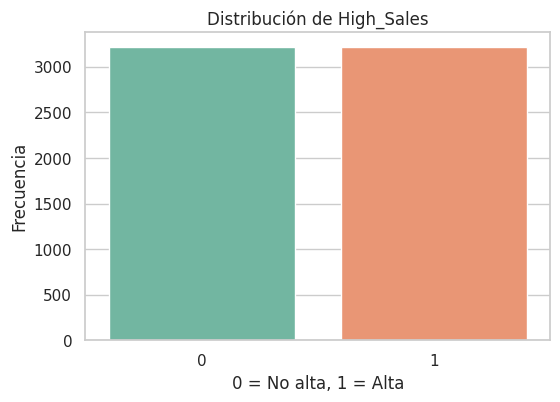

In [ ]:
# ==========================================================
# REGRESIÓN LOGÍSTICA: CREACIÓN DE VARIABLE BINARIA
# ==========================================================
# Para usar regresión logística necesitamos una variable objetivo
# de tipo binario. Aquí transformamos Weekly_Sales en una variable
# llamada High_Sales usando la mediana como punto de corte.

mediana_ventas = df["Weekly_Sales"].median()
df["High_Sales"] = (df["Weekly_Sales"] > mediana_ventas).astype(int)

print("Mediana de ventas usada como umbral:", round(mediana_ventas, 2))
print("\nDistribución de la variable High_Sales:")
print(df["High_Sales"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="High_Sales", palette="Set2")
plt.title("Distribución de High_Sales")
plt.xlabel("0 = No alta, 1 = Alta")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
# ==========================================================
# REGRESIÓN LOGÍSTICA: DEFINICIÓN DE X E y
# ==========================================================
# Usamos las mismas variables explicativas, pero ahora el objetivo
# será clasificar si la semana fue de ventas altas o no.

features_log = ["Holiday_Flag", "Temperature", "Fuel_Price", "CPI", "Unemployment", "Month", "Week", "Quarter"]
X_log = df[features_log]
y_log = df["High_Sales"]

# División entrenamiento/prueba
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42, stratify=y_log
)

# Escalado
# En regresión logística suele ser útil escalar para estabilizar el entrenamiento.
scaler = StandardScaler()
X_train_log_scaled = scaler.fit_transform(X_train_log)
X_test_log_scaled = scaler.transform(X_test_log)

print("Datos listos para clasificación.")
print("Train:", X_train_log.shape)
print("Test :", X_test_log.shape)

Datos listos para clasificación.
Train: (5148, 8)
Test : (1287, 8)


In [ ]:
# ==========================================================
# REGRESIÓN LOGÍSTICA: ENTRENAMIENTO DEL MODELO
# ==========================================================
# Aquí el modelo aprende probabilidades. Posteriormente, con un umbral
# (por defecto 0.5), convierte la probabilidad en clase 0 o 1.

modelo_logistico = LogisticRegression(max_iter=1000)
modelo_logistico.fit(X_train_log_scaled, y_train_log)

coeficientes_log = pd.DataFrame({
    "Variable": X_log.columns,
    "Coeficiente": modelo_logistico.coef_[0]
})

print("Intercepto logístico (β0):", modelo_logistico.intercept_[0])
display(coeficientes_log.sort_values(by="Coeficiente", ascending=False))

Intercepto logístico (β0): 0.0007468594339657386


,Variable,Coeficiente
5,Month,0.737876
2,Fuel_Price,0.039996
0,Holiday_Flag,0.037158
1,Temperature,-0.066484
4,Unemployment,-0.145637
7,Quarter,-0.177441
3,CPI,-0.237206
6,Week,-0.490465


Métricas del modelo de regresión logística
Accuracy : 0.5509
Precision: 0.5509
Recall   : 0.5474
F1-score : 0.5491

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.55      0.55       644
           1       0.55      0.55      0.55       643

    accuracy                           0.55      1287
   macro avg       0.55      0.55      0.55      1287
weighted avg       0.55      0.55      0.55      1287



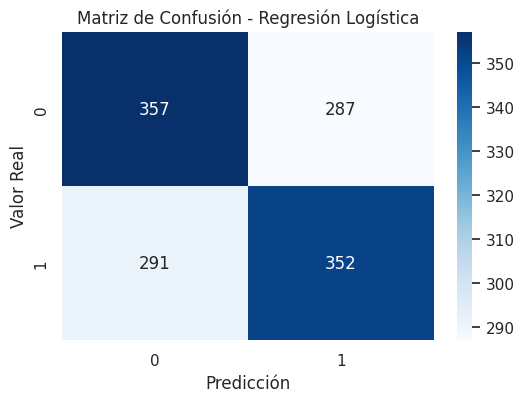

In [ ]:
# ==========================================================
# REGRESIÓN LOGÍSTICA: PREDICCIÓN Y EVALUACIÓN
# ==========================================================
# El modelo entrega:
# - clase predicha
# - probabilidad de la clase positiva

y_pred_log = modelo_logistico.predict(X_test_log_scaled)
y_prob_log = modelo_logistico.predict_proba(X_test_log_scaled)[:, 1]

# Métricas
acc = accuracy_score(y_test_log, y_pred_log)
prec = precision_score(y_test_log, y_pred_log)
rec = recall_score(y_test_log, y_pred_log)
f1 = f1_score(y_test_log, y_pred_log)

print("Métricas del modelo de regresión logística")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_log, y_pred_log))

# Matriz de confusión
cm = confusion_matrix(y_test_log, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.show()

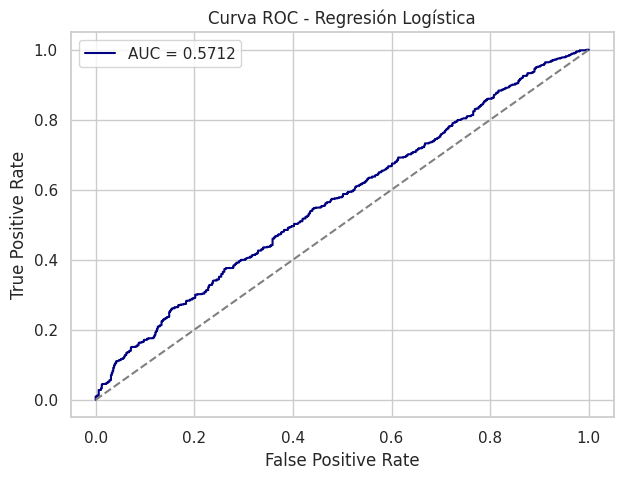

AUC: 0.5712


In [ ]:
# ==========================================================
# REGRESIÓN LOGÍSTICA: CURVA ROC Y AUC
# ==========================================================
# La curva ROC evalúa la capacidad del modelo para separar clases.
# El AUC resume ese desempeño en un solo número:
# - más cerca de 1 = mejor
# - cerca de 0.5 = similar al azar

fpr, tpr, thresholds = roc_curve(y_test_log, y_prob_log)
auc = roc_auc_score(y_test_log, y_prob_log)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}", color="navy")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Regresión Logística")
plt.legend()
plt.show()

print("AUC:", round(auc, 4))

## Interpretación de la matriz de confusión

La matriz de confusión resume aciertos y errores del modelo:

- **TP (True Positive):** semanas que realmente fueron de ventas altas y el modelo clasificó correctamente como altas.
- **TN (True Negative):** semanas que no fueron de ventas altas y el modelo clasificó correctamente como no altas.
- **FP (False Positive):** semanas que no eran de ventas altas, pero el modelo dijo que sí.
- **FN (False Negative):** semanas que sí eran de ventas altas, pero el modelo no las detectó.

## Métricas asociadas

- **Accuracy:** porcentaje total de clasificaciones correctas.
- **Precision:** de todas las semanas predichas como ventas altas, cuántas realmente lo eran.
- **Recall:** de todas las semanas realmente altas, cuántas logró detectar el modelo.
- **F1-score:** balance entre precision y recall.
- **AUC:** capacidad global del modelo para distinguir entre semanas altas y no altas.

# Conclusión general del análisis

## Regresión lineal
Se utilizó para estimar el valor de `Weekly_Sales` como variable continua. Este enfoque es útil cuando el negocio necesita pronosticar montos aproximados de ventas.

## Regresión logística
Se utilizó para clasificar si una semana corresponde o no a un nivel alto de ventas. Este enfoque es útil cuando el negocio necesita tomar decisiones binarias, por ejemplo:

- activar una estrategia promocional
- reforzar inventario
- anticipar semanas de alto desempeño

## Aprendizaje metodológico
Este notebook muestra que un proyecto analítico no comienza directamente con el modelo. Primero se debe:

1. cargar datos
2. explorar datos
3. limpiar y transformar variables
4. definir correctamente la variable objetivo
5. dividir en entrenamiento y prueba
6. entrenar el modelo
7. evaluar resultados
8. interpretar el hallazgo en términos de negocio